In [1]:
import numpy as np
import matplotlib.pyplot as plt
import taichi as ti # pip install taichi if you don't have it

ti.init(arch=ti.cpu)

[Taichi] version 1.7.4, llvm 15.0.1, commit b4b956fd, win, python 3.11.7
[Taichi] Starting on arch=x64


# Yian's code

In [2]:
# Constants
a = 1.0 # lattice constant
m = 1.0 # mass
k = 1e1 # lattice spring constant
ke = 5.0 # next nearest neighbor spring constant
eta = 2*np.sqrt(ke*m)*0.1 # viscous
ko = 5.0 # k12=ko, k21=-ko, non-reciprocal spring constant
fmax = ke * 0.1 * np.sqrt(2) * a # nxyz=333, 0.25 or nxyz=111, 0.2

amp = 1e-2 # perturbation amplitude
omega = np.sqrt(k/m) # frequency

periodicity = 2*np.pi/omega
t_step = 20
dt = periodicity/t_step
print(dt)

g = [0, 3e-1][0] # gravity
gx, gy, gz = g, 0.0, 0.0

0.099345882657961


[242, 561, 840, 200]
[242, 561, 840, 200]


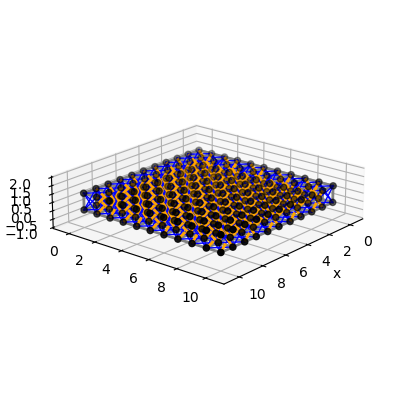

In [3]:
# Initial cube node positions
nxnynz = 10
nx, ny, nz = nxnynz, nxnynz, 1
N_nodes = (nx + 1) * (ny + 1) * (nz + 1)
N_bonds = nx*(ny+1)*(nz+1) + (nx+1)*ny*(nz+1) + (nx+1)*(ny+1)*nz
N_faces = nx*ny*(nz+1) + nx*(ny+1)*nz + (nx+1)*ny*nz
NN_bonds = N_faces * 2

# Nodes
nodes = a * np.array([[i, j, k]
                  for k in range(nz + 1)
                  for j in range(ny + 1)
                  for i in range(nx + 1)])

# Bonds in x-direction
bonds_x = np.array([[((k) * (nx + 1) * (ny + 1) + (j) * (nx + 1) + (i)),
                    ((k) * (ny + 1) * (nx + 1) + (j) * (nx + 1) + (i + 1))]
                   for k in range(nz + 1)
                   for j in range(ny + 1)
                   for i in range(nx + 0)])
# Bonds in y-direction
bonds_y = np.array([[((k) * (nx + 1) * (ny + 1) + (j) * (nx + 1) + (i)),
                    ((k) * (ny + 1) * (nx + 1) + (j + 1) * (nx + 1) + (i))]
                   for k in range(nz + 1)
                   for j in range(ny + 0)
                   for i in range(nx + 1)])
# Bonds in z-direction
bonds_z = np.array([[((k) * (nx + 1) * (ny + 1) + (j) * (nx + 1) + (i)),
                    ((k + 1) * (ny + 1) * (nx + 1) + (j) * (nx + 1) + (i))]
                   for k in range(nz + 0)
                   for j in range(ny + 1)
                   for i in range(nx + 1)])
# Combine all bonds
bonds = np.vstack([bonds_x, bonds_y, bonds_z])


# Next nearest bonds in xy plane
nnbonds_xy = np.array([[((k) * (nx + 1) * (ny + 1) + (j) * (nx + 1) + (i)),
                    ((k) * (ny + 1) * (nx + 1) + (j + 1) * (nx + 1) + (i + 1))]
                   for k in range(nz + 1)
                   for j in range(ny + 0)
                   for i in range(nx + 0)])
nnbonds_yx = np.array([[((k) * (nx + 1) * (ny + 1) + (j) * (nx + 1) + (i + 1)),
                    ((k) * (ny + 1) * (nx + 1) + (j + 1) * (nx + 1) + (i))]
                   for k in range(nz + 1)
                   for j in range(ny + 0)
                   for i in range(nx + 0)])
# Next nearest bonds in yz plane
nnbonds_yz = np.array([[((k) * (nx + 1) * (ny + 1) + (j) * (nx + 1) + (i)),
                    ((k+1) * (ny + 1) * (nx + 1) + (j + 1) * (nx + 1) + (i))]
                   for k in range(nz + 0)
                   for j in range(ny + 0)
                   for i in range(nx + 1)])
nnbonds_zy = np.array([[((k) * (nx + 1) * (ny + 1) + (j + 1) * (nx + 1) + (i)),
                    ((k+1) * (ny + 1) * (nx + 1) + (j) * (nx + 1) + (i))]
                   for k in range(nz + 0)
                   for j in range(ny + 0)
                   for i in range(nx + 1)])
# Next nearest bonds in zx plane
nnbonds_zx = np.array([[((k) * (nx + 1) * (ny + 1) + (j) * (nx + 1) + (i)),
                    ((k+1) * (ny + 1) * (nx + 1) + (j) * (nx + 1) + (i + 1))]
                   for k in range(nz + 0)
                   for j in range(ny + 1)
                   for i in range(nx + 0)])
nnbonds_xz = np.array([[((k) * (nx + 1) * (ny + 1) + (j) * (nx + 1) + (i + 1)),
                    ((k+1) * (ny + 1) * (nx + 1) + (j) * (nx + 1) + (i))]
                   for k in range(nz + 0)
                   for j in range(ny + 1)
                   for i in range(nx + 0)])
# Combine all nnbonds
nnbonds = np.vstack([nnbonds_xy, nnbonds_yx, nnbonds_yz, nnbonds_zy, nnbonds_zx, nnbonds_xz])

# Active bonds in z, x, y directions
abonds_1 = np.array([[((k) * (nx + 1) * (ny + 1) + (j) * (nx + 1) + (i)),
                    ((k+1) * (ny + 1) * (nx + 1) + (j) * (nx + 1) + (i + 1))]
                   for k in range(0, nz + 0)
                   for j in range(0, ny + 0)
                   for i in range((k+j)%2, nx + 0, 2)])
abonds_2 = np.array([[((k) * (nx + 1) * (ny + 1) + (j + 1) * (nx + 1) + (i)),
                    ((k+1) * (ny + 1) * (nx + 1) + (j) * (nx + 1) + (i))]
                   for k in range(0, nz + 0)
                   for j in range(0, ny + 0)
                   for i in range((k+j)%2, nx + 0, 2)])
abonds_3 = np.array([[((k) * (nx + 1) * (ny + 1) + (j + 1) * (nx + 1) + (i + 1)),
                    ((k+1) * (ny + 1) * (nx + 1) + (j + 1) * (nx + 1) + (i))]
                   for k in range(0, nz + 0)
                   for j in range(0, ny + 0)
                   for i in range((k+j)%2, nx + 0, 2)])
abonds_4 = np.array([[((k) * (nx + 1) * (ny + 1) + (j) * (nx + 1) + (i + 1)),
                    ((k+1) * (ny + 1) * (nx + 1) + (j + 1) * (nx + 1) + (i + 1))]
                   for k in range(0, nz + 0)
                   for j in range(0, ny + 0)
                   for i in range((k+j)%2, nx + 0, 2)])
N_abonds_set = len(abonds_1)
N_abonds = N_abonds_set * 4
abonds = np.hstack([abonds_1, abonds_2, abonds_3, abonds_4]).reshape(N_abonds_set*4, 2)
print([N_nodes, N_bonds, NN_bonds, N_abonds])
print([len(nodes), len(bonds), len(nnbonds), len(abonds)])

%matplotlib widget
# %matplotlib inline
def plot_cube(nodes, bonds, nnbonds, abonds):
    plt.close('all')
    fig = plt.figure(figsize=(4,4))
    ax = fig.add_subplot(111, projection='3d')
    ax.view_init(elev=20, azim=40)
    ax.scatter(nodes[:,0], nodes[:,1], nodes[:,2], color='black')
    for bond in bonds:
        x_vals = [nodes[bond[0], 0], nodes[bond[1], 0]]
        y_vals = [nodes[bond[0], 1], nodes[bond[1], 1]]
        z_vals = [nodes[bond[0], 2], nodes[bond[1], 2]]
        ax.plot(x_vals, y_vals, z_vals, color='gray', linewidth=2)
    for bond in nnbonds:
        x_vals = [nodes[bond[0], 0], nodes[bond[1], 0]]
        y_vals = [nodes[bond[0], 1], nodes[bond[1], 1]]
        z_vals = [nodes[bond[0], 2], nodes[bond[1], 2]]
        ax.plot(x_vals, y_vals, z_vals, color='blue', linewidth=1)
    for bond in abonds:
        x_vals = [nodes[bond[0], 0], nodes[bond[1], 0]]
        y_vals = [nodes[bond[0], 1], nodes[bond[1], 1]]
        z_vals = [nodes[bond[0], 2], nodes[bond[1], 2]]
        ax.plot(x_vals, y_vals, z_vals, color='orange', linewidth=2, linestyle='dashed')

    ax.set_xlim([-a, (nx+1)*a])
    ax.set_ylim([-a, (ny+1)*a])
    ax.set_zlim([-a, (nz+1)*a])
    ax.set_xlabel("x")
    ax.set_box_aspect([nx+2, ny+2, nz+2])
    plt.show()
plot_cube(nodes, bonds, nnbonds, abonds)

Convert arrays into vector fields:

In [4]:
# predefine
nodes_ti = ti.Vector.field(3, dtype=ti.f32, shape=N_nodes)
bonds_ti = ti.Vector.field(2, dtype=ti.i32, shape=N_bonds)
nnbonds_ti = ti.Vector.field(2, dtype=ti.i32, shape=NN_bonds)
abonds_ti = ti.Vector.field(2, dtype=ti.i32, shape=N_abonds)

nodes_ti.from_numpy(np.array(nodes, dtype=np.float32))
bonds_ti.from_numpy(np.array(bonds, dtype=np.int32))
nnbonds_ti.from_numpy(np.array(nnbonds, dtype=np.int32))
abonds_ti.from_numpy(np.array(abonds, dtype=np.int32))

pos = ti.Vector.field(3, dtype=ti.f32, shape=N_nodes)
vel = ti.Vector.field(3, dtype=ti.f32, shape=N_nodes)
force = ti.Vector.field(3, dtype=ti.f32, shape=N_nodes)

# plot_cube(nodes_ti.to_numpy(), bonds_ti.to_numpy(), nnbonds_ti.to_numpy(), abonds_ti.to_numpy())

Create perturbation while conserving momentum

In [ ]:
# initialization
@ti.kernel
def initialize():
    center = ti.Vector([0.0, 0.0, 0.0])
    for i in range(N_nodes):
        center += nodes_ti[i]
    center /= N_nodes
    # centralization
    for i in range(N_nodes):
        nodes_ti[i] -= center
        pos[i] = nodes_ti[i]
        vel[i] = [0.0, 0.0, 0.0]

@ti.kernel
def perturbation(): # creates tangential velocity perturbations around the center while 
    # ensuring zero net linear momentum 
    center = ti.Vector([0.0, 0.0, 0.0])
    vmean = ti.Vector([0.0, 0.0, 0.0])
    for i in range(N_nodes):
        center += pos[i]
    center /= N_nodes
    for i in range(N_nodes):
        d = pos[i] - center
        if d.norm() < 1e-4:
            vel[i] = [0.0, 0.0, 0.0]
        else:
            vel[i] = amp * omega * a * d.normalized()
        vmean += vel[i]
    vmean /= N_nodes
    for i in range(N_nodes):
        vel[i] -= vmean #zero linear momentum

@ti.func
def random(x):
    return x * 2 *(ti.random(dtype=ti.f32) - 0.5)
@ti.kernel
def pos_perturbation(): # adds random positional noise to break symmetry
    for i in range(N_nodes):
        pos[i] += [random(amp*a), random(amp*a), random(amp*a) ]

# check linear and angular momentum is conserved
@ti.kernel
def zero_momentum():
    center = ti.Vector([0.0, 0.0, 0.0])
    p = ti.Vector([0.0, 0.0, 0.0])
    l = ti.Vector([0.0, 0.0, 0.0])
    for i in range(N_nodes):
        center += pos[i]
    center /= N_nodes
    for i in range(N_nodes):
        d = pos[i] - center
        l += d.cross(vel[i])
        p += vel[i]
    print([p, l])

    
initialize()
pos_perturbation()
zero_momentum()

In [6]:
# forces
@ti.kernel
def zero_force():
    for i in range(N_nodes):
        force[i] = ti.Vector([m*gx, m*gy, m*gz])

# passive bonds
@ti.kernel
def nodal_f_passive():
    for i in range(N_bonds):
        id0, id1 = bonds_ti[i][0], bonds_ti[i][1]
        d1 = pos[id1] - pos[id0]
        r1 = d1.norm()
        f1 = k * (r1 - a) * d1 / r1
        force[id0] += f1
        force[id1] -= f1

# next nearest bonds
@ti.kernel
def nodal_f_nnbonds():
    for i in range(NN_bonds):
        id0, id1 = nnbonds_ti[i][0], nnbonds_ti[i][1]
        d1 = pos[id1] - pos[id0]
        r1 = d1.norm()
        f1 = ke * (r1 - ti.sqrt(2) * a) * d1 / r1

        v1 = vel[id1] - vel[id0]
        v1n = v1.dot(d1 / r1)
        f_damp = eta * v1n * d1 / r1
        force[id0] += f1 + f_damp
        force[id1] -= f1 + f_damp

# Linear actuators
@ti.func
def bond_length(bond):
    id0, id1 = bond[0], bond[1]
    d = pos[id1] - pos[id0]
    r = d.norm()
    return r

@ti.kernel
def nodal_f_active():
    for i in range(N_abonds_set):
        for j in range(4):
            bond_id0, bond_id1, bond_id2 = ((j-1)%4)+4*i, ((j+0)%4)+4*i, ((j+1)%4)+4*i
            bond0, bond1, bond2 = abonds_ti[bond_id0], abonds_ti[bond_id1], abonds_ti[bond_id2]
            r0 = bond_length(bond0)
            r2 = bond_length(bond2)
            idl, idr = bond1[0], bond1[1]
            d1 = pos[idr] - pos[idl]
            fm = ti.math.clamp(ko * (r2 - r0), -fmax, fmax) # outwards
            f1 = - fm * d1.normalized() 
            force[idl] += f1
            force[idr] += -f1

# Update velocity based on forces
@ti.kernel
def update_velocity():
    for i in vel:
        vel[i] += force[i] / m * dt

# Update positions based on velocity
@ti.kernel
def update_position():
    for i in pos:
        pos[i] += vel[i] * dt

@ti.kernel
def fixed_BC():
    for i in range((nx+1)*(ny+1)):
        pos[i] = nodes_ti[i]
        vel[i] = [0.0, 0.0, 0.0]
        j = (nx+1)*(ny+1)*nz + i
        vel[j] += ( - vel[j].dot(disp_vec)) * disp_vec

disp_vec = ti.Vector([1.0, 0.0, 0.0])
loading_step = t_step * 400
disp = nz * a * 0.2

@ti.kernel
def fixed_loading(ii: ti.i32):
    disp1 = ti.math.clamp(ii/loading_step * disp, 0, disp)
    for j in range((nx+1)*(ny+1)):
        i = (nx+1)*(ny+1)*nz + j
        disp0 = (pos[i] - nodes_ti[i]).dot(disp_vec)
        pos[i] += (disp1 - disp0) * disp_vec
    


Carry out simulation steps:

In [7]:
# Update current configuration
initialize()
pos_perturbation()
zero_momentum()

pos_data = [pos.to_numpy()]
vel_data = [vel.to_numpy()]

save_step = t_step * 2
total_step = t_step * 2000
print(dt, save_step*dt, total_step*dt)

from tqdm import tqdm
for ii in tqdm(range(total_step), desc="Simulating"):
    # fixed_loading(ii)
    zero_force()
    nodal_f_passive()
    nodal_f_nnbonds()
    nodal_f_active()
    update_velocity()
    update_position()
    fixed_BC()
    if ii % save_step == (save_step-1):
        pos_data.append(pos.to_numpy())
        vel_data.append(vel.to_numpy())

print(len(pos_data))

0.099345882657961 3.97383530631844 3973.83530631844


Simulating: 100%|██████████| 40000/40000 [02:30<00:00, 266.51it/s]

1001


Calculate kinetic energy of each vertex and sum them

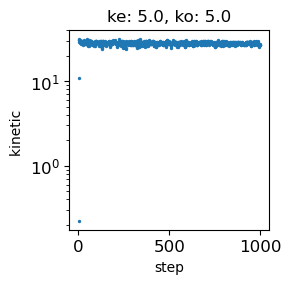

In [8]:
# kinetic energy
N_data = len(vel_data)
time = np.array([dt*save_step*i for i in range(N_data)])
pos_time_ti = ti.Vector.field(3, dtype=ti.f32, shape=(N_data, N_nodes))
vel_time_ti = ti.Vector.field(3, dtype=ti.f32, shape=(N_data, N_nodes))
pos_time_ti.from_numpy(np.array(pos_data, dtype=np.float32))
vel_time_ti.from_numpy(np.array(vel_data, dtype=np.float32))

kinetic_ti = ti.field(dtype=ti.f32, shape=N_data)
@ti.kernel
def kinetic_energy():
    for i in range(N_data):
        for j in range(N_nodes):
            kinetic_ti[i] += 0.5 * m * vel_time_ti[i,j].norm_sqr()
kinetic_energy()

def kinetic_time(plt_step=1):
    kinetic_np = kinetic_ti.to_numpy()[::plt_step]
    
    %matplotlib inline
    plt.close('all')
    plt.rcParams['font.size'] = 12
    plt.rcParams['axes.titlesize'] = 12
    plt.rcParams['axes.labelsize'] = 10
    ax = plt.figure(figsize=(5, 5)).add_axes([0.3, 0.3, 0.4, 0.4])

    # time_np = time[::plt_step]
    # ax.scatter(time_np, kinetic_np, s=2)
    # ax.set_xlabel("time (s)")
 
    length = len(kinetic_np)
    ax.scatter(plt_step * np.arange(length), kinetic_np, s=2)
    ax.set_xlabel("step")
    ax.set_yscale('log')
    ax.set_ylabel("kinetic ")
    ax.set_title(f"ke: {ke}, ko: {ko}")
    plt.show()

kinetic_time()
zero_momentum()

Kinetic energy starts at 0, reaches a steady vale fast.
Below: computes local distorsions of lattice.

In [ ]:
N_cubes = nx*ny*nz
order_time_ti = ti.Vector.field(3, dtype=ti.f32, shape=(N_data, N_cubes))
# order parameters
@ti.func
def order_component(e1, e2, e3):
    ex = e1.normalized()
    ey = e2.normalized()
    ez = e3.normalized()
    szx = ez.dot(ex)
    syz = ez.dot(ey)
    sxy = ex.dot(ey)
    return(ti.Vector([szx, syz, sxy]))
@ti.kernel
def order_parameters():
    for t in range(N_data):
        for k in range(nz):
            for j in range(ny):
                for i in range(nx):
                    id = i + (nx+1)*j + (nx+1)*(ny+1)*k
                    id0, id1 = id, id+1
                    id2, id3 = id1+(nx+1), id0+(nx+1)
                    id4, id5 = id0+(nx+1)*(ny+1), id1+(nx+1)*(ny+1)
                    id6, id7 = id2+(nx+1)*(ny+1), id3+(nx+1)*(ny+1)
                    ex1 = pos_time_ti[t, id1] - pos_time_ti[t, id0]
                    ex2 = pos_time_ti[t, id2] - pos_time_ti[t, id3]
                    ex3 = pos_time_ti[t, id5] - pos_time_ti[t, id4]
                    ex4 = pos_time_ti[t, id6] - pos_time_ti[t, id7]
                    ey1 = pos_time_ti[t, id3] - pos_time_ti[t, id0]
                    ey2 = pos_time_ti[t, id2] - pos_time_ti[t, id1]
                    ey3 = pos_time_ti[t, id7] - pos_time_ti[t, id4]
                    ey4 = pos_time_ti[t, id6] - pos_time_ti[t, id5]
                    ez1 = pos_time_ti[t, id4] - pos_time_ti[t, id0]
                    ez2 = pos_time_ti[t, id5] - pos_time_ti[t, id1]
                    ez3 = pos_time_ti[t, id7] - pos_time_ti[t, id3]
                    ez4 = pos_time_ti[t, id6] - pos_time_ti[t, id2]
                    s = ti.Vector([0.0, 0.0, 0.0])
                    s += order_component(ex1, ey1, ez1)
                    s += order_component(ex1, ey2, ez2)
                    s += order_component(ex2, ey1, ez3)
                    s += order_component(ex2, ey2, ez4)
                    s += order_component(ex3, ey3, ez1)
                    s += order_component(ex3, ey4, ez2)
                    s += order_component(ex4, ey3, ez3)
                    s += order_component(ex4, ey4, ez4)
                    s /= 8
                    id_cubic = nx*ny*k + nx*j + i
                    order_time_ti[t, id_cubic][0] = s[0]
                    order_time_ti[t, id_cubic][1] = s[1]
                    order_time_ti[t, id_cubic][2] = s[2]
order_parameters()
order_time_np = order_time_ti.to_numpy()
order_time_np_mean = order_time_np.mean(1) #Average deformation over all cubes at each time step


Below: plot phase space trajectory of deformations and how it evolves in time with colormap; the second plot is time evolution of each of the 3 shear modes

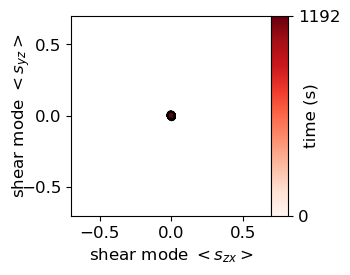

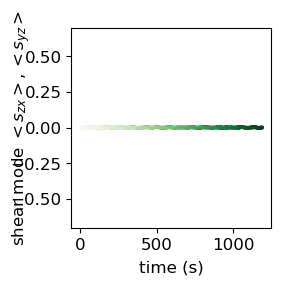

In [10]:
import os
import warnings
from matplotlib.collections import LineCollection
def colored_line(x, y, c, ax, **lc_kwargs):
    if "array" in lc_kwargs:
        warnings.warn('The provided "array" keyword argument will be overridden')
    default_kwargs = {"capstyle": "butt"}
    default_kwargs.update(lc_kwargs)
    x = np.asarray(x)
    y = np.asarray(y)
    x_midpts = np.hstack((x[0], 0.5 * (x[1:] + x[:-1]), x[-1]))
    y_midpts = np.hstack((y[0], 0.5 * (y[1:] + y[:-1]), y[-1]))
    coord_start = np.column_stack((x_midpts[:-1], y_midpts[:-1]))[:, np.newaxis, :]
    coord_mid = np.column_stack((x, y))[:, np.newaxis, :]
    coord_end = np.column_stack((x_midpts[1:], y_midpts[1:]))[:, np.newaxis, :]
    segments = np.concatenate((coord_start, coord_mid, coord_end), axis=1)
    lc = LineCollection(segments, **default_kwargs)
    lc.set_array(c)  # set the colors of each segment
    return ax.add_collection(lc)


# ----------------- plot order parameters -----------------
%matplotlib inline
plt.close('all')
plt.rcParams['font.size'] = 12
plt.rcParams['axes.titlesize'] = 12
plt.rcParams['axes.labelsize'] = 12

total = 300
gap = 1
fig = plt.figure(figsize=(5, 5))
ax = fig.add_axes([0.3, 0.3, 0.4 ,0.4])
color = time
lines = colored_line(order_time_np_mean[0:total:gap,0], order_time_np_mean[0:total:gap,1], color[0:total:gap], ax, 
                        cmap="Reds", linewidth= 2 )
cax = fig.add_axes([0.7, 0.3, 0.4/12, 0.4])
fig.colorbar(lines, ax=ax, cax=cax) 
# fig.colorbar(lines, ax=ax, cax=cax, label=f"time (s)") 

ax.scatter(order_time_np_mean[0:total:gap,0], order_time_np_mean[0:total:gap,1], 
            s=20, c=color[0:total:gap], cmap='Reds', linewidths=1, edgecolors='black', zorder=3) 

ax.text(0.5, -0.2, "shear mode $<s_{zx}>$", fontsize=12, rotation=0, ha='center', va='center', transform=ax.transAxes)
ax.text(-0.25, 0.5, "shear mode $<s_{yz}>$", fontsize=12, rotation=90, ha='center', va='center', transform=ax.transAxes)
ax.text(1.2, 0.5, "time (s)", fontsize=12, rotation=90, ha='center', va='center', transform=ax.transAxes)

xlim = 0.7
xtick = 0.5
ax.set_xlim(-xlim, xlim)
ax.set_ylim(-xlim, xlim)
ax.set_xticks((-xtick, 0, xtick))
ax.set_yticks((-xtick, 0, xtick))
cax.set_yticks((0, total*dt*save_step))


fig2 = plt.figure(figsize=(5, 5))
ax = fig2.add_axes([0.3, 0.3, 0.4 ,0.4])
ax.scatter(time[0:total], order_time_np_mean[0:total,0], s=2, c=color[0:total], cmap='Blues')
ax.scatter(time[0:total], order_time_np_mean[0:total,1], s=2, c=color[0:total], cmap='Reds')
ax.scatter(time[0:total], order_time_np_mean[0:total,2], s=2, c=color[0:total], cmap='Greens')

ax.text(0.5, -0.2, "time (s)", fontsize=12, rotation=0, ha='center', va='center', transform=ax.transAxes)
ax.text(-0.25, 0.5, "shear mode $<s_{zx}>, <s_{yz}>$", fontsize=12, rotation=90, ha='center', va='center', transform=ax.transAxes)
#ax.set_xlim(-xlim, xlim)
ax.set_ylim(-xlim, xlim)

# result_dir =  f'results_metacube/chiral{nx}{ny}{nz}_250306/ko{ko}/'

# os.makedirs(result_dir, exist_ok=True)
# for i, fig in enumerate(plt.get_fignums()):
#     plt.figure(fig)
#     plt.savefig(f'{result_dir}/fig_{i}.pdf', transparent=True )

plt.show()


Takeaway: the shear modes remain at 0 over time. No deformation? Weird. Below: generate movie

In [11]:
# render using GGUI 3D
def video(plt_step=1, close:int=1, save:int=0):
    pos_time_np = pos_time_ti.to_numpy()[::plt_step]
    N_step = len(pos_time_np)

    window = ti.ui.Window(f'odd: {ko}', (400, 400), vsync=True, fps_limit=60, pos =(150,150))
    canvas = window.get_canvas()
    canvas.set_background_color((1, 1, 1))
    scene = window.get_scene()
    camera = ti.ui.Camera()
    camera.up(0, 0, 1)
    view_scale = 0.7
    camera.position(1.3*nx*a*view_scale, 1.4*ny*a*view_scale, 2.9*max(nz,10)*a*view_scale)
    camera.lookat(0.0, 0.0, 0.0)
    gui = window.get_gui()
    pause = False
    step = 0

    if save == 1:
        close = 1
        video_manager = ti.tools.VideoManager(output_dir=result_dir, framerate=60, automatic_build=False)
    
    # ball_radius = a
    # ball_center = ti.Vector.field(3, dtype=ti.f32, shape=1)
    # ball_center[0] = [0.0, 0.0, 0.0]

    while window.running:
        camera.track_user_inputs(window, movement_speed=1, hold_key=ti.ui.RMB)
        scene.set_camera(camera)
        camera.lookat(0.0, 0.0, 0.0)
        scene.ambient_light((0.5, 0.5, 0.5))
        scene.point_light(pos=(1.2*a, 1.2*a, 1.2*a), color=(1, 1, 1))

        for e in window.get_events(ti.ui.PRESS):
            if e.key == ti.ui.ESCAPE:
                window.running = False
            elif e.key == ti.ui.SPACE:
                    pause = not pause
        if window.is_pressed('r'): step = 0
        
        with gui.sub_window("Lattices", 0.00, 0.90, 0.5, 0.1) as w:
                w.text(f"frmae({int(plt_step*N_step)}):{int(plt_step*step)}")

        # background
        # scene.particles(ball_center, radius=ball_radius * 0.98, color=(0.4, 0.4, 0.7))
        
        # initial frame
        # scene.lines(vertices=nodes_ti, indices=bonds_ti, color=(0.7, 0.7, 0.7), width=4.0)
        
        #nodes 
        scene.particles(pos, radius = a * 0.08, color=(0.0, 0.0, 0.0))

        # bonds
        pos.from_numpy(pos_time_np[step])
        scene.lines(vertices=pos, indices=bonds_ti, color=(0.0, 0.0, 0.0), width=8.0)
        scene.lines(vertices=pos, indices=abonds_ti, color=(0.8, 0.4, 0.0), width=8.0)
        
        canvas.scene(scene)
        window.show()

        if save == 1:
            img = window.get_image_buffer_as_numpy()
            video_manager.write_frame(img)
        if not pause:
            step += 1
        if step >= N_step:
            if close == 1:
                window.running = False
            pause = not pause
            step += -1
    if save == 1:
        video_manager.make_video(gif=False, mp4=True)
    
video()


In [130]:
# result_dir =  f'results_metacube/chiral{nx}{ny}{nz}_250828/ko{ko}/'
# os.makedirs(result_dir, exist_ok=True)

# print(result_dir)

In [131]:
# os.environ["PATH"] = "/opt/homebrew/bin:" + os.environ["PATH"]
# video(save=1)

# import ffmpeg
# cwd = os.getcwd() 
# input_file = f'{cwd}/{result_dir}/video.mp4'
# output_file = f'{cwd}/{result_dir}/video_comp_gx.mp4'

# def compress_video(input_file, output_file, crf=28, preset="medium"):
#     try:
#         ffmpeg.input(input_file).output(
#             output_file,
#             vcodec="libx264",  # H.264 codec for best compatibility
#             crf=crf,           # Lower = better quality, higher = smaller file
#             preset=preset,     # Compression speed/quality trade-off
#             acodec="aac",      # Audio codec
#             audio_bitrate="128k"  # Audio bitrate
#         ).run(overwrite_output=True)
#         print(f"Compression successful: {output_file}")
#     except ffmpeg.Error as e:
#         print("Error:", e.stderr.decode())

# compress_video(input_file, output_file, crf=28, preset="fast")

# import shutil
# def clean_frames_and_video(dir):
#     shutil.rmtree(f'{dir}/frames')
#     os.remove(f'{dir}/video.mp4')
# clean_frames_and_video(result_dir)